# 01 — TF-IDF + LogisticRegression tuning

**Owner:** Van (Modeler)  
**MLflow experiment:** `sentiment-tfidf-logreg`  
**Data:** `data/local/gold/gold_50k_training.csv` (gitignored; built by the gold EDA notebook)

Offline experimentation notebook — no Airflow / Postgres / MinIO. Establishes a strong
sklearn baseline that becomes `sentiment-baseline` in the MLflow Registry (thin-slice-first
rule from WORKFLOW.md).

**Metric priority** (social listening — catching negative-sentiment surges):
1. `f1_negative` — primary selection metric
2. `recall_negative` — missing a real negative is the costliest error
3. `precision_negative` — diagnoses over-flagging
4. `f1_macro` — report/reference metric
5. `f1_neutral` — logged, excluded from the selection gate

Experiments: A baseline → B class weights → C neutral oversample → D grid search →
threshold tuning → final eval on test + OOT → register best model.

## [0] Imports and config

In [16]:
from __future__ import annotations

import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, PredefinedSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

# Resolve repo root whether the kernel cwd is repo root or notebooks/
ROOT = Path.cwd()
if not (ROOT / "data" / "local").exists() and (ROOT.parent / "data" / "local").exists():
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "local" / "gold" / "gold_50k_training.csv"
ARTIFACT_DIR = ROOT / "models" / "artifacts"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

LABELS = ["negative", "neutral", "positive"]
LABEL2ID = {l: i for i, l in enumerate(LABELS)}
NEG_IDX = 0  # index of "negative" in LABELS
SEED = 42

print(f"Repo root: {ROOT}")
print(f"Data file exists: {DATA_PATH.exists()}")

Repo root: c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener
Data file exists: True


In [15]:
# MLflow: local Docker server first (host port 5001), file-store fallback.
# docker-compose maps host 5001 -> container 5000 (5000 is often taken on macOS).
import os
import requests

TRACKING_URI = "http://localhost:5001"
try:
    requests.get(TRACKING_URI, timeout=2)
    mlflow.set_tracking_uri(TRACKING_URI)
    # Docker is up — remap MinIO endpoint to localhost so host-side boto3 can reach it.
    # Inside Docker, containers use http://minio:9000 directly; the notebook needs localhost.
    os.environ["MLFLOW_S3_ENDPOINT_URL"] = "http://localhost:9000"
except requests.exceptions.RequestException:
    mlflow.set_tracking_uri(f"file:{(ROOT / 'mlruns').as_posix()}")
    # Docker is down — clear S3 vars so artifacts stay on local filesystem, not MinIO.
    # Without this, boto3 tries http://minio:9000 (Docker-internal hostname) and fails.
    os.environ.pop("MLFLOW_S3_ENDPOINT_URL", None)
    os.environ.pop("AWS_ACCESS_KEY_ID", None)
    os.environ.pop("AWS_SECRET_ACCESS_KEY", None)

mlflow.set_experiment("sentiment-tfidf-logreg")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

MLflow tracking URI: http://localhost:5001


## [1] Data loading and splits

Shared split strategy (identical in `02_distilbert_tuning.ipynb`):

- **OOT** and **demo** are strictly temporal (`review_date` cutoffs).
- **Train / val / test** come from the remaining pool: random shuffle + stratify on label (80/10/10).
- **Demo** is never used for training or evaluation — saved to CSV for `data/ingest/replay.py`.

> **Cutoff note:** the instructions suggested `2022-07-01` / `2022-10-01`, but this export
> spans **2021-05-02 → 2022-04-10**, so those dates would leave OOT and demo empty.
> Cutoffs below were computed from the date quantiles to hit OOT ≈ 10% and demo ≈ 4%:
> rest 85.7% / OOT 10.2% / demo 4.1%.

In [17]:
df = pd.read_csv(DATA_PATH, parse_dates=["review_date"])
df = df.sort_values("review_date").reset_index(drop=True)

# ── Temporal holdouts ──────────────────────────────────────────────────────────
# Adjusted to this export's actual range (2021-05-02 → 2022-04-10) so that
# OOT ≈ 10% and demo ≈ 4% of total rows.
OOT_CUTOFF = "2021-12-11"
DEMO_CUTOFF = "2022-01-09"

demo_df = df[df.review_date >= DEMO_CUTOFF].copy()
oot_df = df[(df.review_date >= OOT_CUTOFF) & (df.review_date < DEMO_CUTOFF)].copy()
rest_df = df[df.review_date < OOT_CUTOFF].copy()

# ── Random splits from rest_df ─────────────────────────────────────────────────
# 80 / 10 / 10 of rest_df (~86% of total) → approx 69/9/9 of total
rest_df = rest_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

train_df, temp_df = train_test_split(
    rest_df, test_size=0.2, stratify=rest_df["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=SEED
)

# ── Sanity check ───────────────────────────────────────────────────────────────
for name, split in [("train", train_df), ("val", val_df), ("test", test_df),
                    ("oot", oot_df), ("demo", demo_df)]:
    dist = split.label.value_counts(normalize=True).round(3).to_dict()
    print(f"{name:6s}  n={len(split):>6,}  {dist}")

train   n=34,413  {'positive': 0.716, 'negative': 0.212, 'neutral': 0.072}
val     n= 4,302  {'positive': 0.716, 'negative': 0.212, 'neutral': 0.072}
test    n= 4,302  {'positive': 0.716, 'negative': 0.212, 'neutral': 0.072}
oot     n= 5,147  {'positive': 0.704, 'negative': 0.217, 'neutral': 0.079}
demo    n= 2,056  {'positive': 0.739, 'negative': 0.198, 'neutral': 0.063}


In [18]:
# ── Save demo/replay files ─────────────────────────────────────────────────────
# Window A: representative clean sample
demo_df.sample(n=min(500, len(demo_df)), random_state=SEED).to_csv(
    ROOT / "data" / "sample" / "demo_window_a_clean.csv", index=False
)
# Window B: poisoned — oversample negatives to simulate a brand crisis
neg = demo_df[demo_df.label == "negative"]
other_pool = demo_df[demo_df.label != "negative"]
other = other_pool.sample(n=min(100, len(other_pool)), random_state=SEED)
pd.concat([neg, other]).sample(frac=1, random_state=SEED).to_csv(
    ROOT / "data" / "sample" / "demo_window_b_poisoned.csv", index=False
)
print("Demo replay files saved.")

Demo replay files saved.


### Shared evaluation function

Called on **val, test, and OOT** for every experiment run.

In [19]:
def evaluate(y_true, y_pred, split_name: str, log_to_mlflow: bool = True) -> dict:
    """Compute and optionally log all metrics for a given split."""
    metrics = {
        f"{split_name}_f1_negative":        f1_score(y_true, y_pred, labels=[NEG_IDX], average="macro"),
        f"{split_name}_recall_negative":    recall_score(y_true, y_pred, labels=[NEG_IDX], average="macro"),
        f"{split_name}_precision_negative": precision_score(y_true, y_pred, labels=[NEG_IDX], average="macro"),
        f"{split_name}_f1_macro":           f1_score(y_true, y_pred, average="macro"),
        f"{split_name}_f1_neutral":         f1_score(y_true, y_pred, labels=[1], average="macro"),
        f"{split_name}_f1_positive":        f1_score(y_true, y_pred, labels=[2], average="macro"),
    }
    print(f"\n── {split_name.upper()} ──")
    print(classification_report(y_true, y_pred, target_names=LABELS))
    if log_to_mlflow:
        mlflow.log_metrics(metrics)
    return metrics

## [2] Preprocessing

In [20]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+", "", text)          # remove URLs
    text = re.sub(r"[^a-z0-9\s]", " ", text)    # keep alphanumeric
    text = re.sub(r"\s+", " ", text).strip()
    return text


train_df["clean_text"] = train_df["text"].map(clean_text)
val_df["clean_text"] = val_df["text"].map(clean_text)
test_df["clean_text"] = test_df["text"].map(clean_text)
oot_df["clean_text"] = oot_df["text"].map(clean_text)

# Encode labels
y_train = train_df["label"].map(LABEL2ID).values
y_val = val_df["label"].map(LABEL2ID).values
y_test = test_df["label"].map(LABEL2ID).values
y_oot = oot_df["label"].map(LABEL2ID).values

train_df[["clean_text", "label"]].head(3)

,clean_text,label
40186,cute spot and amazing coffee drinks friendly s...,positive
37219,i love wawa mainly for their iced coffee but t...,positive
3620,a gift card prompted a lunch visit during the ...,positive


## [3] Experiment A — Baseline (no imbalance handling)

In [21]:
with mlflow.start_run(run_name="logreg-baseline"):
    mlflow.log_params({"tfidf_ngram": "(1,2)", "tfidf_max_features": 50000,
                       "lr_C": 1.0, "class_weight": "none"})

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000)),
        ("clf",   LogisticRegression(max_iter=1000, random_state=SEED)),
    ])
    pipe.fit(train_df["clean_text"], y_train)

    evaluate(y_val,  pipe.predict(val_df["clean_text"]),  "val")
    evaluate(y_test, pipe.predict(test_df["clean_text"]), "test")
    evaluate(y_oot,  pipe.predict(oot_df["clean_text"]),  "oot")


── VAL ──
              precision    recall  f1-score   support

    negative       0.85      0.88      0.86       910
     neutral       0.45      0.11      0.17       310
    positive       0.92      0.98      0.95      3082

    accuracy                           0.90      4302
   macro avg       0.74      0.66      0.66      4302
weighted avg       0.87      0.90      0.88      4302


── TEST ──
              precision    recall  f1-score   support

    negative       0.84      0.89      0.86       911
     neutral       0.55      0.15      0.24       309
    positive       0.93      0.98      0.95      3082

    accuracy                           0.90      4302
   macro avg       0.77      0.67      0.69      4302
weighted avg       0.88      0.90      0.88      4302


── OOT ──
              precision    recall  f1-score   support

    negative       0.84      0.87      0.86      1119
     neutral       0.56      0.17      0.26       407
    positive       0.92      0.98      0.

## [4] Experiment B — Class weights

In [22]:
with mlflow.start_run(run_name="logreg-class-weights"):
    mlflow.log_params({"tfidf_ngram": "(1,2)", "tfidf_max_features": 50000,
                       "lr_C": 1.0, "class_weight": "balanced"})

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000)),
        ("clf",   LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
    ])
    pipe.fit(train_df["clean_text"], y_train)

    evaluate(y_val,  pipe.predict(val_df["clean_text"]),  "val")
    evaluate(y_test, pipe.predict(test_df["clean_text"]), "test")
    evaluate(y_oot,  pipe.predict(oot_df["clean_text"]),  "oot")


── VAL ──
              precision    recall  f1-score   support

    negative       0.84      0.87      0.85       910
     neutral       0.35      0.51      0.42       310
    positive       0.97      0.92      0.94      3082

    accuracy                           0.88      4302
   macro avg       0.72      0.76      0.74      4302
weighted avg       0.90      0.88      0.89      4302


── TEST ──
              precision    recall  f1-score   support

    negative       0.84      0.87      0.86       911
     neutral       0.38      0.55      0.45       309
    positive       0.97      0.92      0.95      3082

    accuracy                           0.88      4302
   macro avg       0.73      0.78      0.75      4302
weighted avg       0.90      0.88      0.89      4302


── OOT ──
              precision    recall  f1-score   support

    negative       0.82      0.86      0.84      1119
     neutral       0.36      0.52      0.43       407
    positive       0.97      0.91      0.

## [5] Experiment C — Oversample neutral

Upsample neutral rows in the **training set only** — never touch val/test/oot.

In [23]:
neutral_rows = train_df[train_df.label == "neutral"]
neutral_up = resample(neutral_rows, replace=True, n_samples=8000, random_state=SEED)
train_balanced = pd.concat([
    train_df[train_df.label != "neutral"], neutral_up
]).sample(frac=1, random_state=SEED)
y_train_bal = train_balanced["label"].map(LABEL2ID).values

print("Balanced train label counts:", train_balanced.label.value_counts().to_dict())

with mlflow.start_run(run_name="logreg-oversample-neutral"):
    mlflow.log_params({"neutral_oversample_n": 8000, "class_weight": "balanced"})

    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1, 2), max_features=50000)),
        ("clf",   LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED)),
    ])
    pipe.fit(train_balanced["clean_text"], y_train_bal)

    evaluate(y_val,  pipe.predict(val_df["clean_text"]),  "val")
    evaluate(y_test, pipe.predict(test_df["clean_text"]), "test")
    evaluate(y_oot,  pipe.predict(oot_df["clean_text"]),  "oot")

Balanced train label counts: {'positive': 24656, 'neutral': 8000, 'negative': 7284}

── VAL ──
              precision    recall  f1-score   support

    negative       0.83      0.87      0.85       910
     neutral       0.36      0.46      0.41       310
    positive       0.97      0.93      0.95      3082

    accuracy                           0.88      4302
   macro avg       0.72      0.75      0.74      4302
weighted avg       0.90      0.88      0.89      4302


── TEST ──
              precision    recall  f1-score   support

    negative       0.83      0.88      0.86       911
     neutral       0.41      0.51      0.46       309
    positive       0.97      0.93      0.95      3082

    accuracy                           0.89      4302
   macro avg       0.74      0.78      0.75      4302
weighted avg       0.90      0.89      0.89      4302


── OOT ──
              precision    recall  f1-score   support

    negative       0.82      0.88      0.85      1119
     neutra

## [6] Experiment D — Hyperparameter tuning (GridSearchCV)

Scored on `f1_negative`. The val split is used as the single held-out fold via
`PredefinedSplit` so GridSearch does not reshuffle the temporal structure.
72 candidates × 1 fold — expect this to take a while on CPU.

In [24]:
neg_f1_scorer = make_scorer(f1_score, labels=[NEG_IDX], average="macro")

param_grid = {
    "tfidf__ngram_range":  [(1, 1), (1, 2), (1, 3)],
    "tfidf__max_features": [30000, 50000, 100000],
    "clf__C":              [0.1, 1.0, 5.0, 10.0],
    "clf__class_weight":   ["balanced", None],
}

pipe = Pipeline([
    ("tfidf", TfidfVectorizer()),
    ("clf",   LogisticRegression(max_iter=1000, random_state=SEED)),
])

# -1 = training fold, 0 = validation fold
X_search = pd.concat([train_df["clean_text"], val_df["clean_text"]])
y_search = np.concatenate([y_train, y_val])
fold_flag = [-1] * len(train_df) + [0] * len(val_df)
ps = PredefinedSplit(fold_flag)

with mlflow.start_run(run_name="logreg-gridsearch"):
    gs = GridSearchCV(pipe, param_grid, scoring=neg_f1_scorer,
                      cv=ps, n_jobs=-1, verbose=1, refit=True)
    gs.fit(X_search, y_search)

    mlflow.log_params({k: str(v) for k, v in gs.best_params_.items()})
    mlflow.log_metric("best_cv_f1_negative", gs.best_score_)

    evaluate(y_test, gs.predict(test_df["clean_text"]), "test")
    evaluate(y_oot,  gs.predict(oot_df["clean_text"]),  "oot")

    best_logreg_pipe = gs.best_estimator_

print("Best params:", gs.best_params_)

Fitting 1 folds for each of 72 candidates, totalling 72 fits

── TEST ──
              precision    recall  f1-score   support

    negative       0.85      0.90      0.87       911
     neutral       0.54      0.24      0.33       309
    positive       0.94      0.98      0.96      3082

    accuracy                           0.91      4302
   macro avg       0.78      0.71      0.72      4302
weighted avg       0.89      0.91      0.90      4302


── OOT ──
              precision    recall  f1-score   support

    negative       0.84      0.89      0.86      1119
     neutral       0.51      0.25      0.33       407
    positive       0.94      0.98      0.96      3621

    accuracy                           0.90      5147
   macro avg       0.76      0.70      0.72      5147
weighted avg       0.88      0.90      0.89      5147

Best params: {'clf__C': 10.0, 'clf__class_weight': None, 'tfidf__max_features': 100000, 'tfidf__ngram_range': (1, 3)}


## [7] Threshold tuning on best model

Lower the decision bar for the negative class: if `P(negative) >= t`, predict negative,
otherwise keep the argmax prediction. Tuned on **val** only.

Best threshold for f1_negative: 0.46


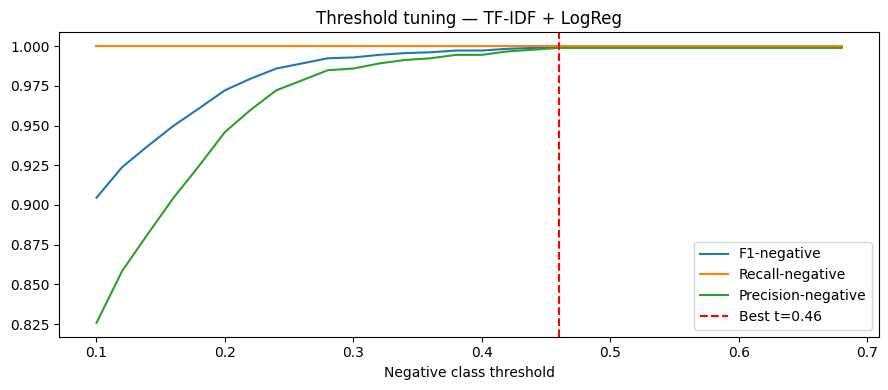

In [25]:
val_probs_neg = best_logreg_pipe.predict_proba(val_df["clean_text"])[:, NEG_IDX]
val_base_preds = best_logreg_pipe.predict(val_df["clean_text"])

thresholds = np.arange(0.10, 0.70, 0.02)
results = []
for t in thresholds:
    preds = np.where(val_probs_neg >= t, NEG_IDX, val_base_preds)
    results.append({
        "threshold":          t,
        "f1_negative":        f1_score(y_val, preds, labels=[NEG_IDX], average="macro"),
        "recall_negative":    recall_score(y_val, preds, labels=[NEG_IDX], average="macro"),
        "precision_negative": precision_score(y_val, preds, labels=[NEG_IDX], average="macro"),
    })

results_df = pd.DataFrame(results)
best_threshold = results_df.loc[results_df.f1_negative.idxmax(), "threshold"]
print(f"Best threshold for f1_negative: {best_threshold:.2f}")

plt.figure(figsize=(9, 4))
plt.plot(results_df.threshold, results_df.f1_negative,        label="F1-negative")
plt.plot(results_df.threshold, results_df.recall_negative,    label="Recall-negative")
plt.plot(results_df.threshold, results_df.precision_negative, label="Precision-negative")
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best t={best_threshold:.2f}")
plt.xlabel("Negative class threshold")
plt.legend()
plt.title("Threshold tuning — TF-IDF + LogReg")
plt.tight_layout()
threshold_plot_path = ROOT / "notebooks" / "logreg_threshold_curve.png"
plt.savefig(threshold_plot_path)
plt.show()

## [8] Final evaluation on test + OOT

Best grid-search config + best threshold. These numbers go in the report.

In [26]:
def predict_with_threshold(pipe, texts, threshold):
    probs = pipe.predict_proba(texts)[:, NEG_IDX]
    base = pipe.predict(texts)
    return np.where(probs >= threshold, NEG_IDX, base)


with mlflow.start_run(run_name="logreg-final"):
    mlflow.log_params({**{k: str(v) for k, v in gs.best_params_.items()},
                       "neg_threshold": best_threshold})
    mlflow.log_artifact(str(threshold_plot_path))

    final_test_metrics = evaluate(
        y_test, predict_with_threshold(best_logreg_pipe, test_df["clean_text"], best_threshold), "test"
    )
    final_oot_metrics = evaluate(
        y_oot, predict_with_threshold(best_logreg_pipe, oot_df["clean_text"], best_threshold), "oot"
    )

    final_run_id = mlflow.active_run().info.run_id


── TEST ──
              precision    recall  f1-score   support

    negative       0.84      0.90      0.87       911
     neutral       0.54      0.24      0.33       309
    positive       0.94      0.98      0.96      3082

    accuracy                           0.91      4302
   macro avg       0.77      0.71      0.72      4302
weighted avg       0.89      0.91      0.90      4302


── OOT ──
              precision    recall  f1-score   support

    negative       0.84      0.89      0.86      1119
     neutral       0.50      0.24      0.33       407
    positive       0.94      0.98      0.96      3621

    accuracy                           0.90      5147
   macro avg       0.76      0.70      0.72      5147
weighted avg       0.88      0.90      0.89      5147



## [9] Register best model to MLflow

Registers as **`sentiment-baseline`**. Promote to `Staging` manually in the MLflow UI
before the FastAPI shadow deploy can load it.

In [27]:
joblib.dump(best_logreg_pipe, ARTIFACT_DIR / "tfidf_logreg_best.pkl")
print(f"Saved pickle: {ARTIFACT_DIR / 'tfidf_logreg_best.pkl'}")

with mlflow.start_run(run_id=final_run_id):
    mlflow.sklearn.log_model(
        best_logreg_pipe,
        artifact_path="model",
        registered_model_name="sentiment-baseline",
    )
print("Registered: sentiment-baseline")

Saved pickle: c:\SMU_MITB\MLE\CS611_MLE\social_listener_project\Machine-Learning-Engineering-Group-9-Social-Listener\models\artifacts\tfidf_logreg_best.pkl


Registered model 'sentiment-baseline' already exists. Creating a new version of this model...
2026/06/10 14:05:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: sentiment-baseline, version 3


Registered: sentiment-baseline


Created version '3' of model 'sentiment-baseline'.
